In [41]:
import pandas as pd
df = pd.read_csv('chickwts.csv')
df.head()

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [2]:
df.groupby('feed')['weight'].mean().sort_values()

,weight
feed,
horsebean,160.200000
linseed,218.750000
soybean,246.428571
meatmeal,276.909091
casein,323.583333
sunflower,328.916667


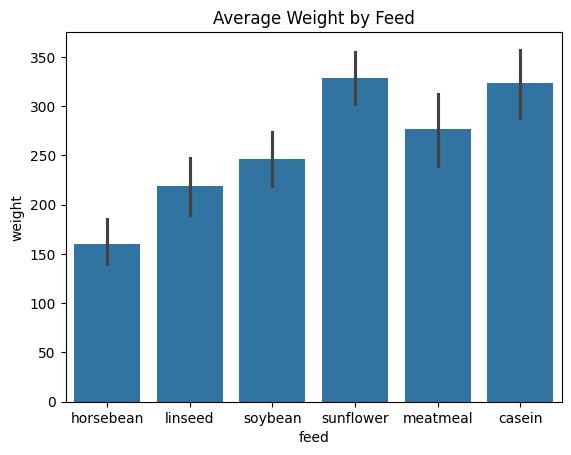

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data = df, x = 'feed', y = 'weight')
plt.title('Average Weight by Feed')
plt.xlabel('feed')
plt.ylabel('weight')
plt.show()

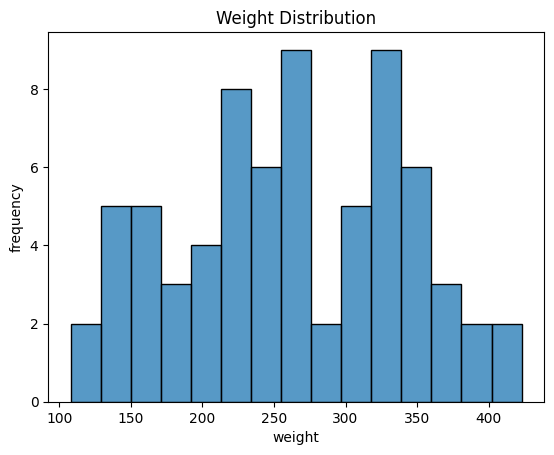

In [6]:
sns.histplot(data = df, x = 'weight', bins = 15)
plt.title('Weight Distribution')
plt.xlabel('weight')
plt.ylabel('frequency')
plt.show()

In [27]:
df2 = pd.read_csv('museum_visitors.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2.head()

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


In [28]:
df2 = df2.set_index('Date')
df2.head()

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
Date,,,,
2014-01-01,24778,4486,1581,6602
2014-02-01,18976,4172,1785,5029
2014-03-01,25231,7082,3229,8129
2014-04-01,26989,6756,2129,2824
2014-05-01,36883,10858,3676,10694


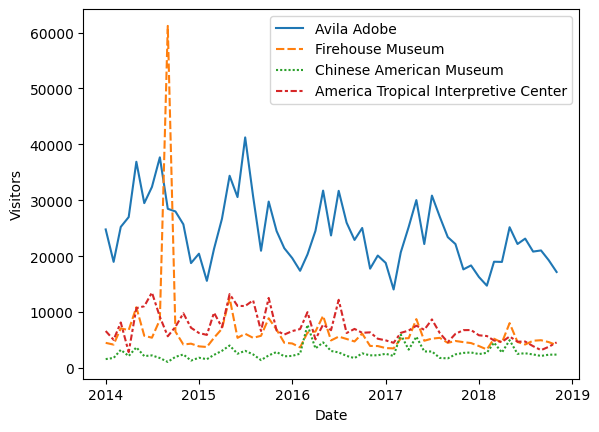

In [30]:
sns.lineplot(data=df2)
plt.title=("Museum Visitors Over time")
plt.xlabel('Date')
plt.ylabel('Visitors')
plt.show()

I converted the date column into the date time format and also moved the dates into the index to make charting easier.

Firehouse museum had the most visitors between 2014 and 2015

In [31]:
df3 = pd.read_csv('sales_clean-3.csv')
df3.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


<Axes: xlabel='qty', ylabel='revenue'>

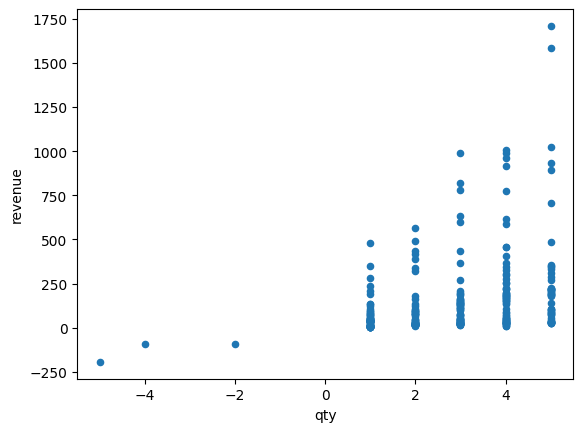

In [35]:
df3['revenue'] = df3['price'] * df3['qty']
df3.plot.scatter(x='qty', y='revenue')

<Axes: >

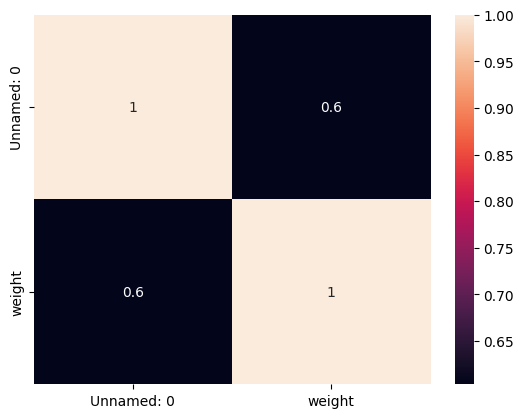

In [36]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

The top left and bottom left have the strongest off-diagonal correlation

Null Hypothesis: There isn't a difference in weight between the horsebean and sunflower feeds.

In [39]:
from scipy.stats import ttest_ind
a = df[df['feed'] == 'horsebean']['weight']
b = df[df['feed'] == 'sunflower']['weight']
ttest_ind(a,b)

TtestResult(statistic=np.float64(-8.848346742516636), pvalue=np.float64(2.374350767683717e-08), df=np.float64(20.0))

After conducting a t-test on the two feed groups, the p-value is below 0.05 with an effect size of 20 grams between the weights of the chickens sampled. This data only comes from one farm so I would conduct more testing across farms to see if the data is consistent.